# This notebook describes work done in support of closing Issue #511.
It uses the stage-by-stage debugger as the base and then adds on analysis at the bottom. for clarity you can skip a lot of the debugger parts and go down to the spatial disaggregation, which is where the meat of the analysis is.

# Pipeline Stage-by-Stage Debugger

A debugging notebook where **each pipeline sub-step gets its own cell** so
we can inspect each intermediate step in isolation — before moving to the next cell. This helps us understand how the method works, how different steps in the process impact the results, and diagnose and resolve any issues.

Every cell calls `inspect()`, which:
1. Runs the same three formal QA checks (`all_nan`, `out_of_range`,
   `sporadic_nan_days`) from `srm.qa_checks` — the same checks a
   `bcsd qa` run applies to a cached artifact.
2. Prints a PASS/FAIL verdict per check.
3. Plots a spatial map (`time=0`) and a domain-mean time series.
4. Registers the computed array in the `STEPS` dict so the cross-stage
   evolution plots at the bottom can iterate over every step.



In [1]:
import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray as xr
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from srm.bcsd_config import BCSDConfig, PipelineOptions
from srm.downscaling_utils import (
    calculate_doy_means,
    downscale_from_coarse,
    get_historical_experiment,
    get_obs,
    interpolate_coarse_to_fine_grid,
    interpolate_fine_to_coarse_grid,
    retrend,
    subset_space,
)
from srm.pipeline import BCSDPipeline
from srm.qa_checks import _STATUS_SYMBOL, run_artifact_checks
from srm.validation import CheckStatus

warnings.filterwarnings("ignore", category=FutureWarning)


def _step_title(step: str, width: int = 16) -> str:
    """Wrap a snake_case step name to fit in a narrow subplot title."""
    return textwrap.fill(step.replace("_", " "), width=width)

## Config

**Edit only this cell** between debug runs. Set `SCENARIO = None` to debug
Stage 1 + Stage 2 only; set a scenario string to also exercise Stage 3.

`scratch_dir` and `output_dir` point to a local tmp directory so no debug
writes touch the real S3 cache.


In [2]:
# ── Edit these values ──────────────────────────────────────────────────────────
GCM = "CESM2-WACCM"
VARIABLE = "pr"
ENSEMBLE_MEMBER = "008"  # CESM2-WACCM SSP245/G6-1.5K uses numeric IDs; "001" → hist r1i1p1f1
SCENARIO = "SSP245"  # None → Stage 1+2 only; set e.g. "SSP245" / "G6-1.5K" to also exercise Stage 3

# Eastern africa - focus on a spot with funky precipitation grid artifacts like in #511
SUBSET_BOUNDS = (-5, 16, 34, 48)
# ──────────────────────────────────────────────────────────────────────────────

config = BCSDConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    # predict_period_start must equal the scenario data start (2015 for SSP245)
    # so stitch_historical_scenario produces a gap-free 1978–end timeseries.
    predict_period_start=2015 if SCENARIO else None,
    predict_period_end=2060 if SCENARIO else None,
    subset_bounds=SUBSET_BOUNDS,
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug",
    environment="debug",
)
pipeline = BCSDPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")
print(f"Scenario: {config.scenario!r}")
print(f"Predict period: {config.predict_period_start}–{config.predict_period_end}")

Run: CESM2-WACCM_pr_008_SSP245_subset
Subset bounds: (-5.0, 16.0, 34.0, 48.0)
Scenario: 'SSP245'
Predict period: 2015–2060


## Inspection helper

`inspect(da, stage)` is called after every sub-step. It:
- `.compute()`s the DataArray (fine for the small subset region)
- Runs `run_artifact_checks()` (skipped for arrays with a `dayofyear` dim
  instead of a `time` dim, since those lack the time axis the checks need)
- Prints a PASS/FAIL line per check with detail for any non-PASS result
- Plots spatial map + domain-mean series
- Registers `da` in `STEPS` and its NaN fraction in `STEP_NAN_FRACTIONS`


In [3]:
STEPS: dict[str, xr.DataArray] = {}  # ordered; keys = step labels
STEP_NAN_FRACTIONS: dict[str, float] = {}  # per-step nan_fraction for bar chart


def inspect(
    da: xr.DataArray,
    stage: str,
    *,
    skip_qa: bool = False,
) -> xr.DataArray:
    """Compute, QA-check, plot, and register a pipeline intermediate."""
    print(f"\n{'=' * 60}")
    print(f"  {stage}")
    print(f"{'=' * 60}")

    da = da.compute()
    STEPS[stage] = da

    has_time = "time" in da.dims
    has_doy = "dayofyear" in da.dims

    # ── QA checks ─────────────────────────────────────────────────────────────
    if not skip_qa and has_time:
        results = run_artifact_checks(
            da,
            gcm=config.gcm,
            variable=config.variable,
            ensemble_member=config.ensemble_member,
            scenario=config.scenario,
            stage=stage,
        )
        STEP_NAN_FRACTIONS[stage] = results["all_nan"].nan_fraction
        for check_name, result in results.items():
            sym = _STATUS_SYMBOL[result.status]
            line = f"  {sym} {check_name}: {result.status.upper()}"
            if result.message:
                line += f" — {result.message}"
            print(line)
            if result.status not in (CheckStatus.PASS, CheckStatus.SKIP) and result.detail:
                for k, v in result.detail.items():
                    print(f"        {k}: {v}")
    elif has_doy:
        print("  (QA checks skipped — dayofyear dimension, no time axis)")
    else:
        print("  (QA checks skipped)")

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"  shape: {dict(da.sizes)}")
    if has_time or has_doy:
        nan_frac = float(np.isnan(da.values).mean())
        print(f"  NaN:   {nan_frac:.4f} ({nan_frac * 100:.2f}%)")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(stage, fontsize=12, fontweight="bold")
    try:
        if has_time:
            da.isel(time=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("time=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean time series")
        elif has_doy:
            da.isel(dayofyear=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("dayofyear=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean DOY series")
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "no time/dayofyear dim", transform=ax.transAxes, ha="center")
    except Exception as exc:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                f"plot error:\n{exc}",
                transform=ax.transAxes,
                ha="center",
                fontsize=8,
                wrap=True,
            )
    plt.tight_layout()
    plt.show()
    return da

## ERA5-relative exceedance helpers

Adapted from `synced/notebooks/check_reasonable_ranges.ipynb`. Unlike the
global physical-bounds check in `qa_checks.py`, these compare the downscaled
output against ERA5's **per-pixel** historical min/max — so a value that is
physically plausible globally but implausible at that specific location is
still flagged.

`obs_fine_s2` / `obs_fine_s3` (already in memory) serve as the ERA5
reference, so no extra S3 reads are needed.


In [4]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    _HAS_CARTOPY = True
except ImportError:
    _HAS_CARTOPY = False

_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Grey for zero exceedances; continuous Reds for nonzero — makes clean regions
# immediately obvious without needing a separate mask plot.
_EXCEEDANCE_CMAP = plt.cm.Reds.copy()
_EXCEEDANCE_CMAP.set_under("lightgrey")


def _era5_threshold(obs_fine: xr.DataArray, direction: str, period: str) -> xr.DataArray:
    """Per-pixel ERA5 min/max from obs_fine already in memory.

    Parameters
    ----------
    obs_fine : already-computed fine-grid ERA5 DataArray
    direction : "gt" → max threshold; "lt" → min threshold
    period    : "annual" or "monthly"
    """
    fn = "max" if direction == "gt" else "min"
    if period == "annual":
        return getattr(obs_fine, fn)("time").compute()
    return getattr(obs_fine.groupby("time.month"), fn)("time").compute()


def _count_exceedances(
    da: xr.DataArray,
    threshold: xr.DataArray,
    direction: str,
    period: str,
) -> xr.DataArray:
    """Number of time steps per pixel that exceed the given threshold."""
    if period == "annual":
        mask = da > threshold if direction == "gt" else da < threshold
        return mask.sum("time").compute()
    counts = []
    for m, group in da.groupby("time.month"):
        exceeded = (
            group > threshold.sel(month=m) if direction == "gt" else group < threshold.sel(month=m)
        )
        counts.append(exceeded.sum("time").expand_dims(month=[m]))
    return xr.concat(counts, dim="month").compute()


def _plot_map(da, ax, title, **kw):
    """Single-panel map with optional cartopy coastlines."""
    proj_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    da.plot(ax=ax, **kw, **proj_kw)
    if _HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=9)


def plot_time_extremes(da: xr.DataArray, label: str) -> None:
    """2×2 grid: time-min and time-max with default and robust color scaling."""
    proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), subplot_kw=proj)
    fig.suptitle(f"{label} — time extremes", fontweight="bold")
    _plot_map(da.min("time"), axes[0, 0], "time min")
    _plot_map(da.max("time"), axes[0, 1], "time max")
    _plot_map(da.min("time"), axes[1, 0], "time min (robust)", robust=True)
    _plot_map(da.max("time"), axes[1, 1], "time max (robust)", robust=True)
    plt.tight_layout()
    plt.show()


def check_era5_exceedances(
    da: xr.DataArray,
    obs_fine: xr.DataArray,
    label: str,
    period: str = "annual",
) -> None:
    """Flag pixels where da ever exceeds ERA5's per-pixel historical min/max.

    Prints pixel counts and plots exceedance maps (grey = clean, Reds = flagged).
    Set period="monthly" for a 3×4 faceted map — slower but more granular.
    """
    print(f"\n── ERA5-relative exceedance: {label} ({period}) ──")
    n_pixels = int(da.isel(time=0).size)

    for direction, label_suffix in [("gt", "days > ERA5 max"), ("lt", "days < ERA5 min")]:
        thresh = _era5_threshold(obs_fine, direction, period)
        count = _count_exceedances(da, thresh, direction, period)

        n_flagged = int((count > 0).sum().values)
        pct = n_flagged / n_pixels
        sym = "✗" if n_flagged > 0 else "✓"
        print(f"  {sym} {label_suffix}: {n_flagged}/{n_pixels} pixels flagged ({pct:.1%})")

        proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
        if period == "annual":
            fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=proj)
            _plot_map(count, ax, f"{label}\n{label_suffix}", cmap=_EXCEEDANCE_CMAP, vmin=0.5)
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(3, 4, figsize=(20, 10), subplot_kw=proj)
            fig.suptitle(f"{label}\n{label_suffix}", fontsize=11)
            for i, ax in enumerate(axes.flat):
                _plot_map(
                    count.sel(month=i + 1),
                    ax,
                    _MONTH_NAMES[i],
                    cmap=_EXCEEDANCE_CMAP,
                    vmin=0.5,
                )
            plt.tight_layout()
            plt.show()

## Stage 1 — `prepare_observations`

Replicates the internals of `BCSDPipeline.prepare_observations` step by step. The final cell writes the result to the debug cache so Stage 2's `_load_gcm_obs()` can find it.


In [5]:
# ── obs_fine: fine-resolution ERA5 observations ───────────────────────────────
obs_fine = get_obs(var=config.variable, dataset_name=config.obs_dataset)
obs_fine = obs_fine.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    obs_fine = subset_space(obs_fine, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max))
train_slice = slice(str(config.train_period_start), str(config.train_period_end))
obs_fine = obs_fine.sel(time=train_slice)

In [6]:
# ── model_grid: GCM historical run (used only as a coarse grid template) ──────
model_grid = get_historical_experiment(
    gcm=config.gcm, member=pipeline._hist_member, var=config.variable
)
model_grid = model_grid.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    model_grid = subset_space(
        model_grid, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max)
    )
model_grid = model_grid.sel(time=train_slice)

In [7]:
# ── obs_coarse: ERA5 obs regridded to the GCM coarse grid ─────────────────────
obs_coarse_stage1 = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=model_grid
)

In [8]:
%%time
# ── Write to debug cache so Stage 2 _load_gcm_obs() can find obs_regridded ───
# This is equivalent to running prepare_observations() but on the debug branch.
# force=True overwrites any previous debug-branch artifact.
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
prepare_obs_path = pipeline.prepare_observations(force=True)
print(f"  → {prepare_obs_path}")

Writing obs_coarse to debug cache via prepare_observations(force=True) ...
  2026-07-28T22:43:47.126068Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-07-28T22:43:47.520013Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  → /tmp/bcsd-debug/scratch/debug/CESM2-WACCM-ERA5-lat-5.0to16.0_lon34.0to48.0.icechunk
CPU times: user 3min 15s, sys: 58 s, total: 4min 13s
Wall time: 25.1 s


## Stage 2 — `fit_historical` (debiasing + spatial downscaling)


In [9]:
%%time
# ── _load_gcm_obs: reload from debug cache + load obs_fine, model_hist ────────
obs_coarse, obs_fine_s2, model_hist = pipeline._load_gcm_obs()

  2026-07-28T22:44:12.237303Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-07-28T22:44:12.238257Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

CPU times: user 85.5 ms, sys: 7.09 ms, total: 92.6 ms
Wall time: 332 ms


In [10]:
%%time
# ── _apply_bias_correction: ibicus QuantileMapping on historical period ────────
# It calls .values / .load() internally so it is always eager; runtime ~ 1–5 min
# on the South Africa subset.
debiased_coarse = pipeline._apply_bias_correction(obs_coarse, model_hist)

CPU times: user 6.81 s, sys: 7.28 s, total: 14.1 s
Wall time: 7.64 s


### Spatial disaggregation sub-steps (Stage 2)

The single `_apply_spatial_downscaling()` call is expanded into five named
intermediates (Cells A–E) plus a consistency check (Cell F), so each step
can be inspected independently. These mirror the internals of
`downscale_from_coarse()` exactly.

> **Cell A** and **Cell B** compute the obs climatology, which is
> scenario-independent. The arrays will be reused in Stage 3 (starting from
> Cell C) so those cells do not need to rerun them.



  obs_fine_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 85, 'lon': 57}
  NaN:   0.0000 (0.00%)


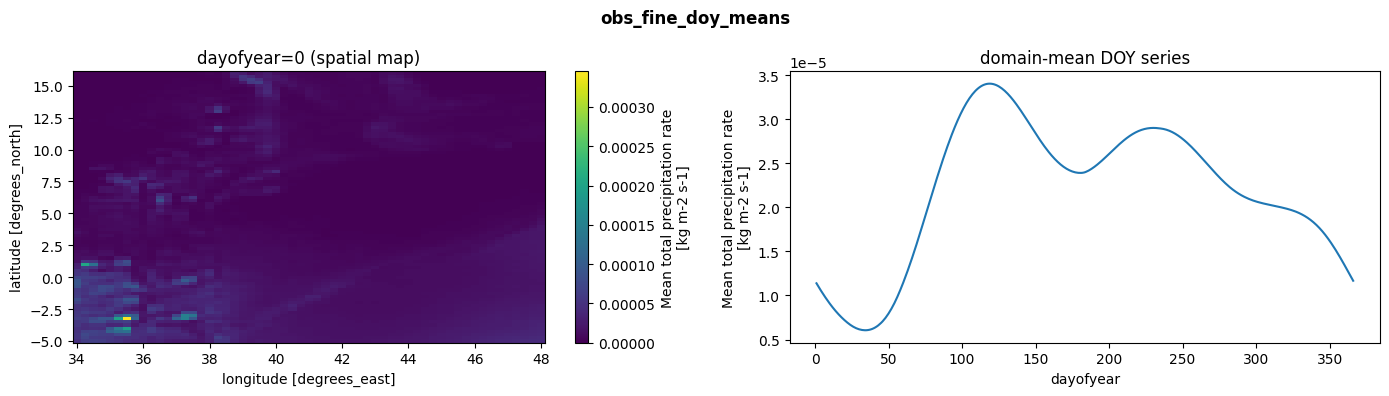

CPU times: user 1min 58s, sys: 31.9 s, total: 2min 30s
Wall time: 18.8 s


In [11]:
%%time
# ── Cell A: fine-grid day-of-year climatology ──────────────────────────────────
# Uses the downscaling_clim_method from config (typically "fft" for most vars).
# allow_negative_values=False mirrors production (_apply_spatial_downscaling):
# FFT smoothing can push a near-zero climatology below 0 for strictly-positive
# variables (pr, rsds), so those artifacts are clamped to 0 here.
obs_fine_doy_means = calculate_doy_means(
    obs_fine_s2,
    clim_method=config.variable_config.downscaling_clim_method,
    allow_negative_values=False,
)
obs_fine_doy_means = inspect(obs_fine_doy_means, "obs_fine_doy_means")

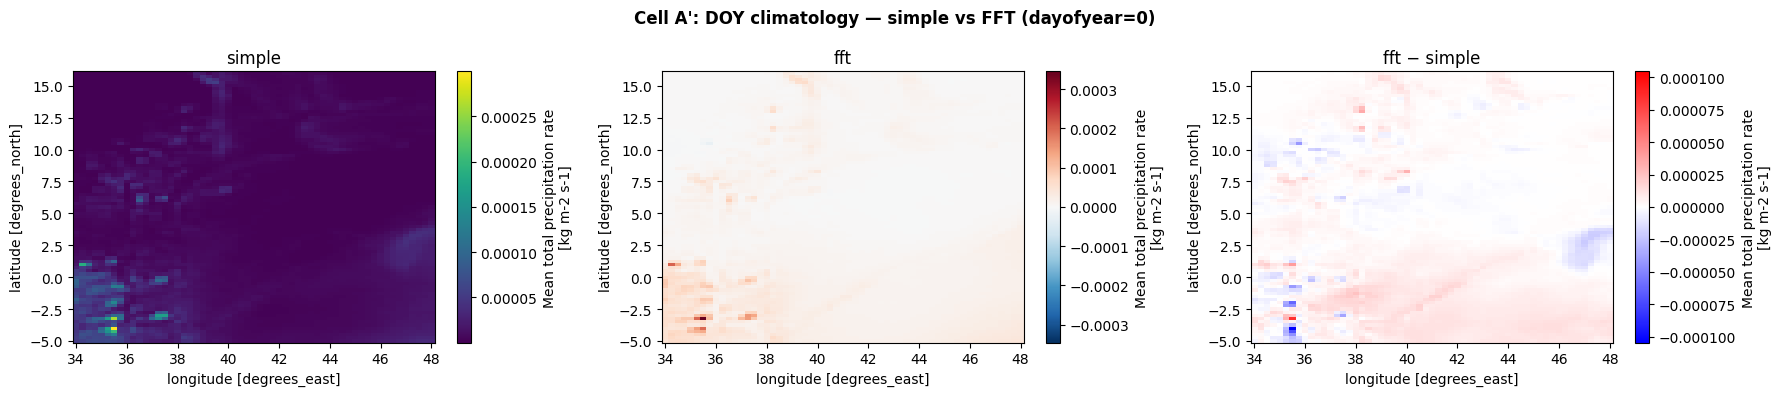

CPU times: user 2min 10s, sys: 35.7 s, total: 2min 46s
Wall time: 16.8 s


In [12]:
%%time
# ── Cell A': FFT vs simple climatology comparison ─────────────────────────────
# Three-panel map: simple | fft | diff (bwr, center=0) for dayofyear=0.
# Reveals FFT-smoothing artifacts found in prior QA notebooks. Uses the raw fft
# (allow_negative_values default True) on purpose, so any sub-zero artifacts that
# Cell A clamps to 0 for strictly-positive variables stay visible here.
obs_fine_doy_means_simple = calculate_doy_means(obs_fine_s2, clim_method="simple")
obs_fine_doy_means_fft = calculate_doy_means(obs_fine_s2, clim_method="fft")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Cell A': DOY climatology — simple vs FFT (dayofyear=0)", fontweight="bold")
kw = dict(add_colorbar=True)
obs_fine_doy_means_simple.isel(dayofyear=0).plot(ax=axes[0], **kw)
axes[0].set_title("simple")
obs_fine_doy_means_fft.isel(dayofyear=0).plot(ax=axes[1], **kw)
axes[1].set_title("fft")
diff = (obs_fine_doy_means_fft - obs_fine_doy_means_simple).isel(dayofyear=0)
diff.plot(ax=axes[2], cmap="bwr", center=0, **kw)
axes[2].set_title("fft − simple")
plt.tight_layout()
plt.show()


  obs_coarse_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 22, 'lon': 11}
  NaN:   0.0000 (0.00%)


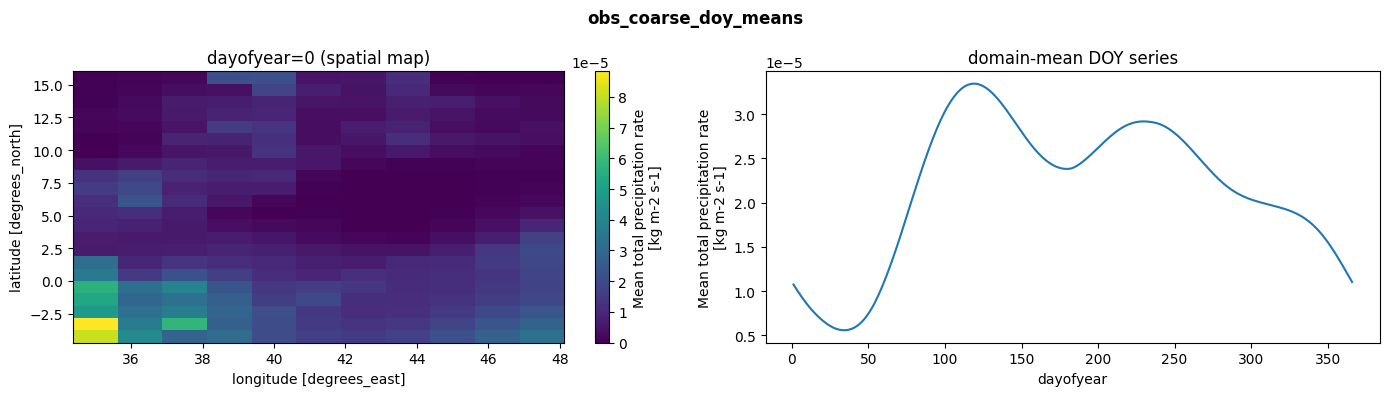

In [13]:
# ── Cell B: coarsen DOY climatology to GCM grid ───────────────────────────────
obs_coarse_doy_means = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine_doy_means, da_coarse_grid=obs_coarse
)
obs_coarse_doy_means = inspect(obs_coarse_doy_means, "obs_coarse_doy_means")


  residuals_coarse
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 71.17% of values outside [0, 0.03]
        out_of_range_fraction: 0.7117253365655696
        actual_min: 0.0
        actual_max: 100.0
        expected_min: 0
        expected_max: 0.03
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 22, 'lon': 11}
  NaN:   0.0000 (0.00%)


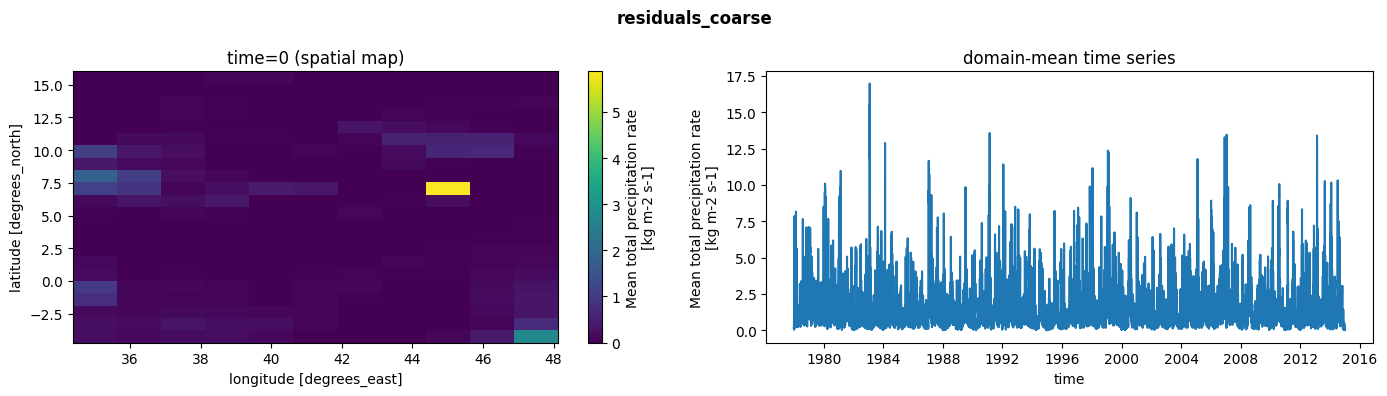

In [67]:
# ── Cell C: coarse spatial residuals (debiased vs coarse climatology) ─────────
if config.variable_config.downscaling_method == "additive":
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") - obs_coarse_doy_means
elif config.variable_config.downscaling_method == "multiplicative":
    # Mirror downscale_from_coarse()'s zero-guarded ratio: where the coarse
    # climatology is exactly 0 (dry cells/days) the ratio is forced to 0 rather
    # than producing inf/NaN, then clipped at max_residual (production default 100).
    max_residual = 100000
    zero_clim = obs_coarse_doy_means == 0
    safe_clim = obs_coarse_doy_means.where(~zero_clim)  # zeros -> NaN
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") / safe_clim
    zero_clim_on_time = zero_clim.sel(dayofyear=debiased_coarse["time"].dt.dayofyear)
    residuals_coarse_1e6 = residuals_coarse.where(~zero_clim_on_time, 0.0).clip(max=max_residual)
    residuals_coarse_100 = residuals_coarse.where(~zero_clim_on_time, 0.0).clip(max=100)
residuals_coarse_100 = inspect(residuals_coarse_100, "residuals_coarse")

# Analysis!

Let's inspect the largest residuals along the time dimension, grouped by month.

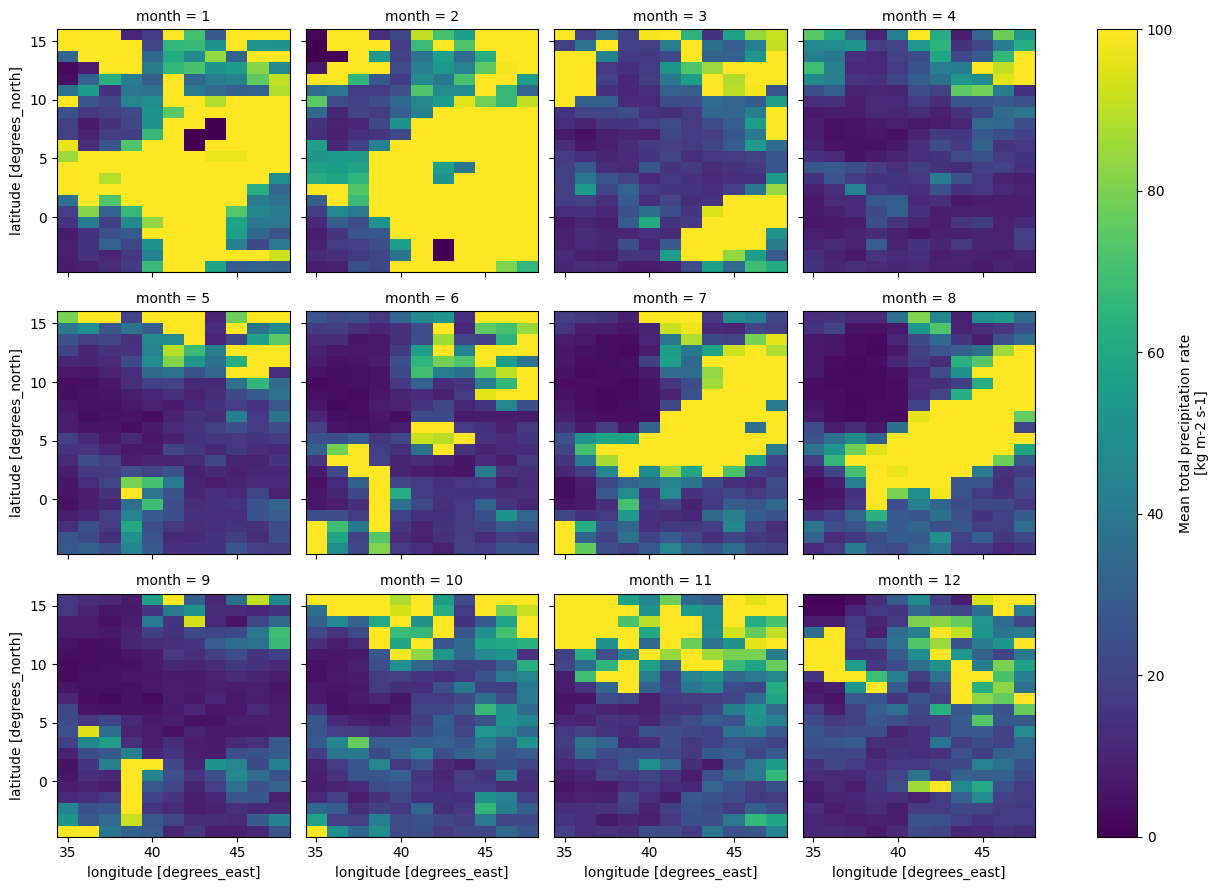

In [49]:
residuals_coarse_100.groupby('time.month').max().plot(col='month', col_wrap=4)

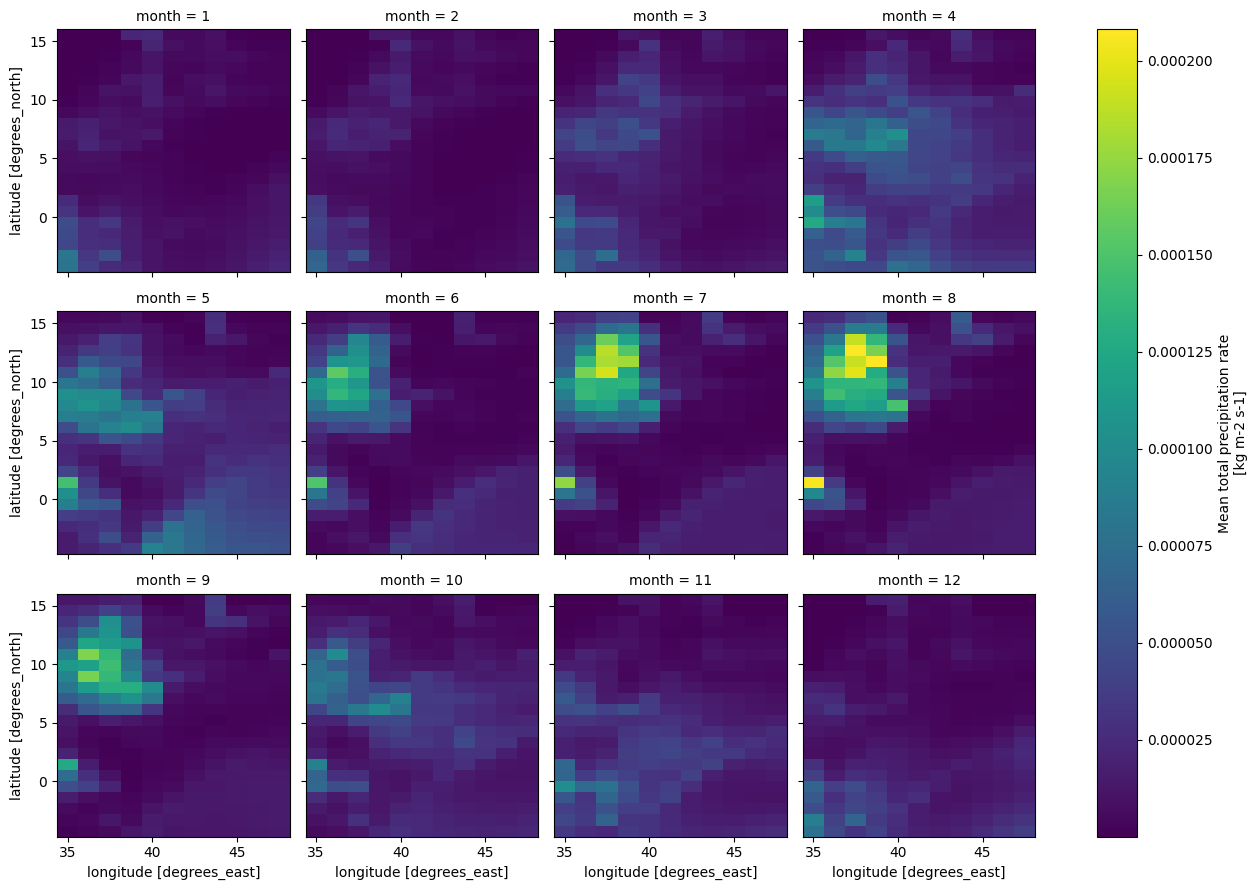

In [50]:
obs_coarse.groupby('time.month').mean().plot(col='month', col_wrap=4)

The residuals are high at times of the year when precipitation is low. We can see that more clearly in the scatter plots below.

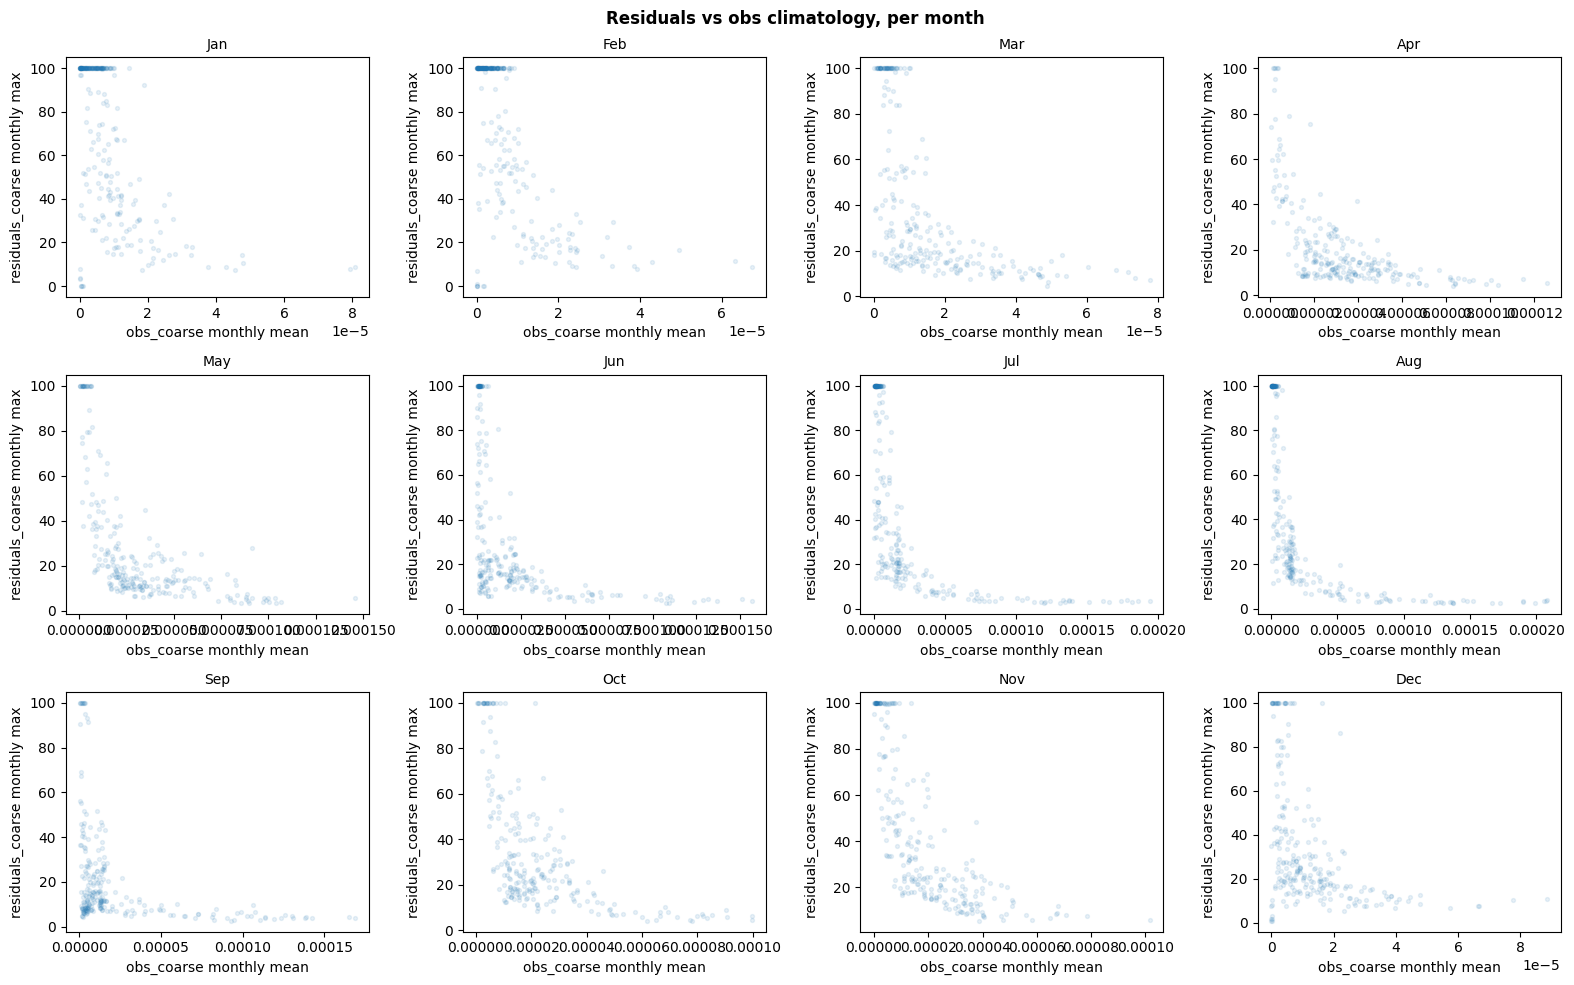

In [51]:
# ── Scatter: obs climatology vs residuals, per month ──────────────────────────
# x = obs_coarse monthly mean (climatology), y = residuals_coarse monthly max,
# one panel per calendar month, points = grid cells.
obs_month_mean = obs_coarse.groupby("time.month").mean()
residuals_month_max = residuals_coarse_100.groupby("time.month").max()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    month = i + 1
    x = obs_month_mean.sel(month=month).values.ravel()
    y = residuals_month_max.sel(month=month).values.ravel()
    valid = ~np.isnan(x) & ~np.isnan(y)
    ax.scatter(x[valid], y[valid], s=8, alpha=0.1)
    ax.set_title(_MONTH_NAMES[i], fontsize=10)
    ax.set_xlabel("obs_coarse monthly mean")
    ax.set_ylabel("residuals_coarse monthly max")
fig.suptitle("Residuals vs obs climatology, per month", fontweight="bold")
plt.tight_layout()
plt.show()

Those residuals then end up getting smeared into neighboring gridcells through the interpolation step.


  residuals_fine
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 77.14% of values outside [0, 0.03]
        out_of_range_fraction: 0.7714323485645159
        actual_min: 0.0
        actual_max: 100.0
        expected_min: 0
        expected_max: 0.03
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 85, 'lon': 57}
  NaN:   0.1684 (16.84%)


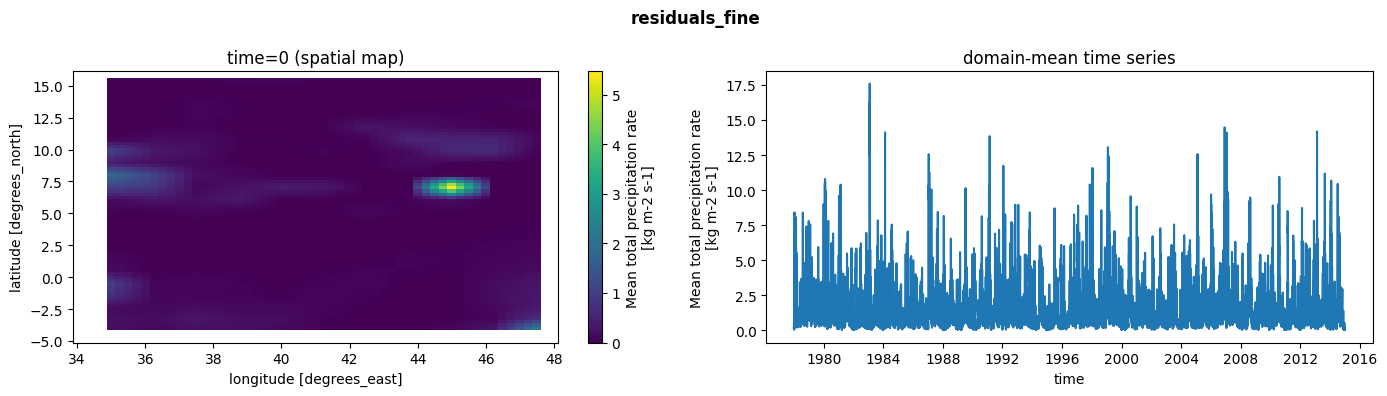

In [70]:
# ── Cell D: interpolate residuals to fine grid ────────────────────────────────
residuals_fine_1e6 = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=residuals_coarse_1e6, da_fine_grid=obs_fine_s2
)
residuals_fine_100 = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=residuals_coarse_100, da_fine_grid=obs_fine_s2
)
residuals_fine_100 = inspect(residuals_fine_100, "residuals_fine")

We can inspect an individual problematic grid cell to check it out. I chose this one by finding the highest residual pixel when they weren't clipped to 100 but rather 1e6.

In [40]:
lat = 11
lon = 37.25

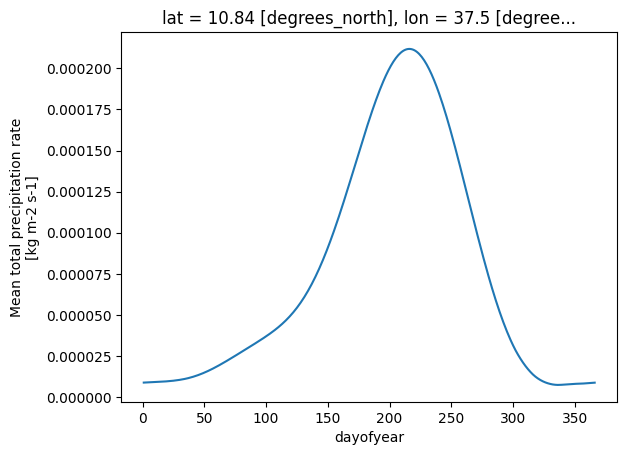

In [41]:
safe_clim.sel(lat=lat, lon=lon, method='nearest').plot()

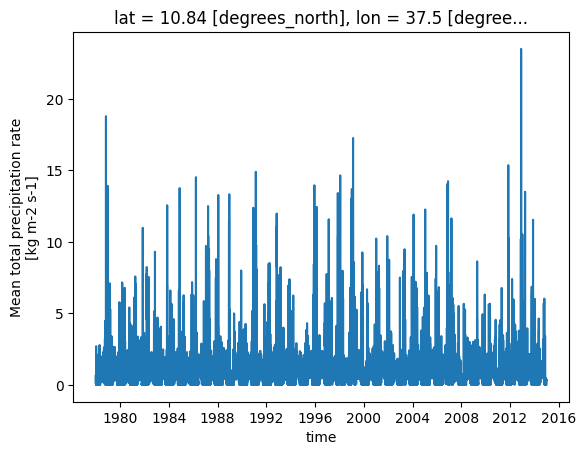

In [42]:
residuals_coarse.sel(lat=lat, lon=lon, method='nearest').plot()


  downscaled
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 0.00% of values outside [0, 0.03]
        out_of_range_fraction: 4.389516834678638e-06
        actual_min: 0.0
        actual_max: 0.266252726316452
        expected_min: 0
        expected_max: 0.03
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 85, 'lon': 57}
  NaN:   0.1684 (16.84%)


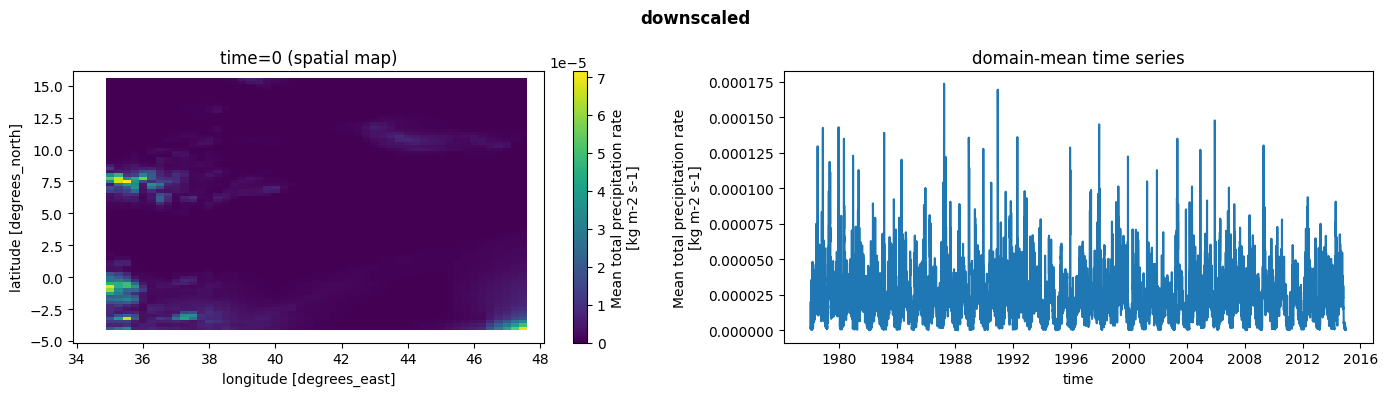

In [72]:
# ── Cell E: reapply fine-grid DOY climatology → final downscaled field ─────────
if config.variable_config.downscaling_method == "additive":
    downscaled = residuals_fine.groupby("time.dayofyear") + obs_fine_doy_means
elif config.variable_config.downscaling_method == "multiplicative":
    downscaled_100 = residuals_fine_100.groupby("time.dayofyear") * obs_fine_doy_means
    downscaled_1e6 = residuals_fine_1e6.groupby("time.dayofyear") * obs_fine_doy_means    
downscaled = inspect(downscaled, "downscaled")

How does this clipping of the residuals play out? Normally we end up with only capping precipitation events in dry places.

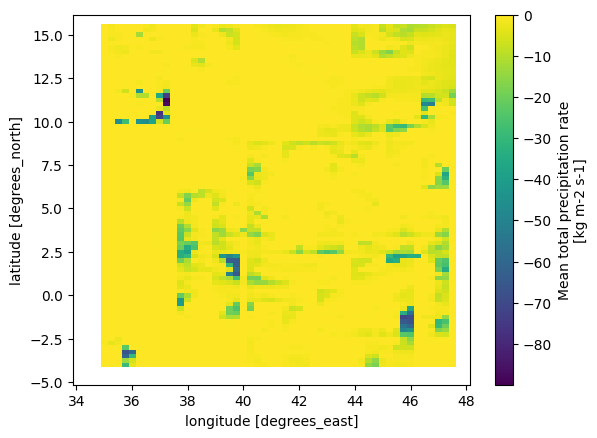

In [76]:
bias = downscaled_100.mean(dim='time') - downscaled_1e6.mean(dim='time')
pbias = bias / downscaled_1e6.mean(dim='time') * 100
pbias.plot()

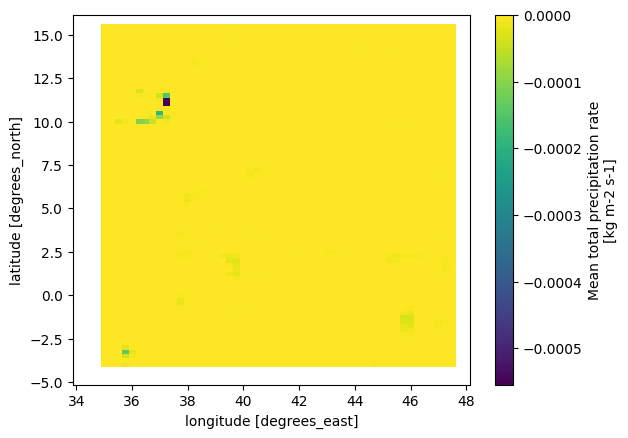

In [77]:
bias.plot()

But sometimes we actually do lose a decent amount of water - take for example the location plotted above with a hot spot of difference when you clip at 100 compared to 1e6.

In [86]:
lat = 11.25
lon = 37.25
bias.sel(lat=lat, lon=lon).values

array(-0.00054713, dtype=float32)

For this pixel, we can see how the residuals can impart issues and also how much water we're losing.

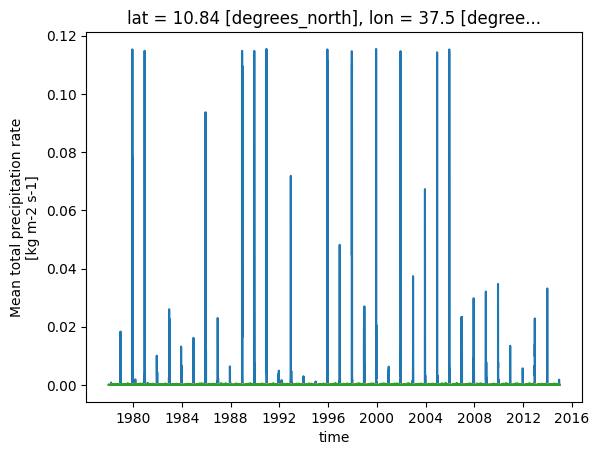

In [92]:
downscaled_1e6.sel(lat=lat, lon=lon).plot()
downscaled_100.sel(lat=lat, lon=lon).plot()
obs_coarse.sel(lat=lat, lon=lon, method='nearest').plot()

Unclipped, the residuals make events blow up! By capping them we keep the events at a reasonable scale.

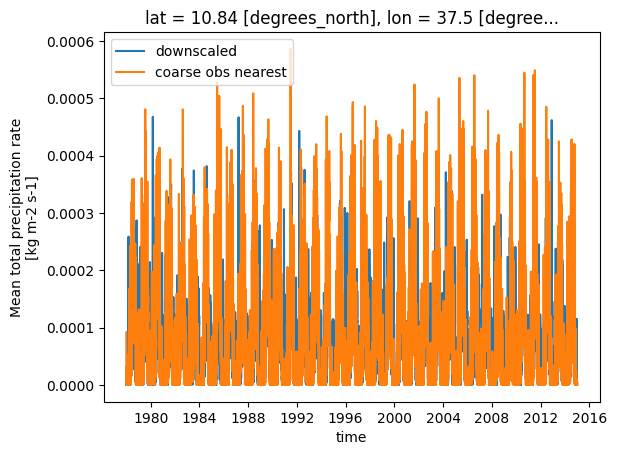

In [94]:
downscaled_100.sel(lat=lat, lon=lon).plot(label='downscaled')
obs_coarse.sel(lat=lat, lon=lon, method='nearest').plot(label='coarse obs nearest')
plt.legend()

We can look at one individual event to see why it happened:


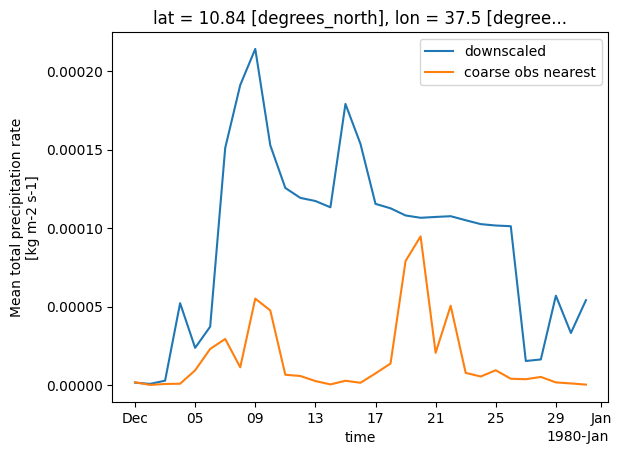

In [109]:
downscaled_100.sel(lat=lat, 
                   lon=lon).sel(time=slice('1979-12-01', 
                                           '1979-12-31')).plot(label='downscaled')
obs_coarse.sel(lat=lat, 
                   lon=lon, method='nearest').sel(time=slice('1979-12-01', 
                                           '1979-12-31')).plot(label='coarse obs nearest')
plt.legend()

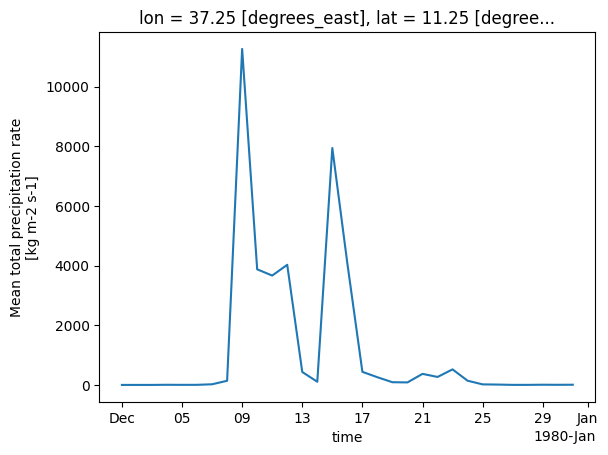

In [110]:
residuals_fine_1e6.sel(lat=lat, lon=lon).sel(time=slice('1979-12-01', 
                                           '1979-12-31')).plot(label='residual from unclipped')

On December 9, 1980, this pixel happened to get a precipitation event when normally the region is very dry in the obs. As a result, you divide a normal precipitation value by a very small number, and create a residual (in the coarse) that gets then also spread around in the interpolation. If this interpolation is in an area with highly heterogeneous precipitation patterns, that residual could be amplified dramatically.

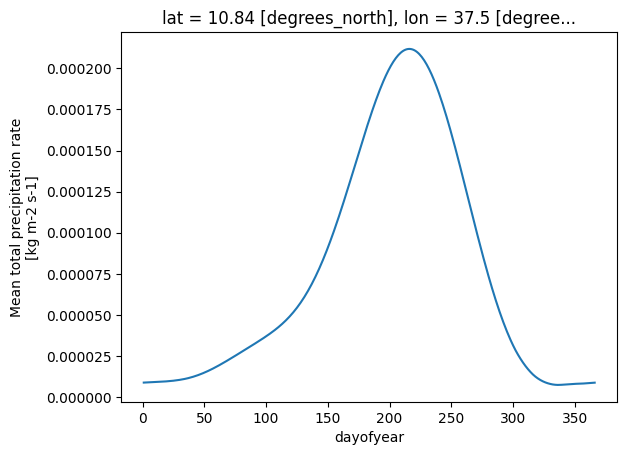

In [103]:
safe_clim.sel(lat=lat, lon=lon, method='nearest').plot()

We can keep track of the situations when the residuals are hitting their cap, and they can be used as a flag to understand the dataset's limitations. Below we can see places that exceeded a residual of 100 more than 2% of the simulation. Any instance like that is primed to blow up, and so we clipped them in our dataset.

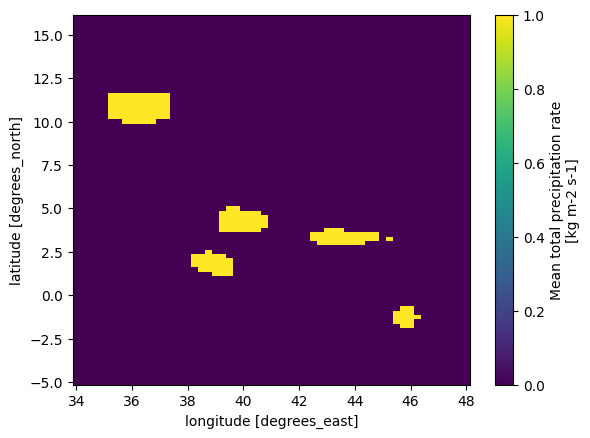

In [142]:
length_of_record = len(residuals_fine_1e6)
((residuals_fine_1e6>100).sum(dim='time')>length_of_record*0.02).plot()

To select one of those pixels, we can see that all of them happen in the same month, which is the dry month of the seasonal cycle.

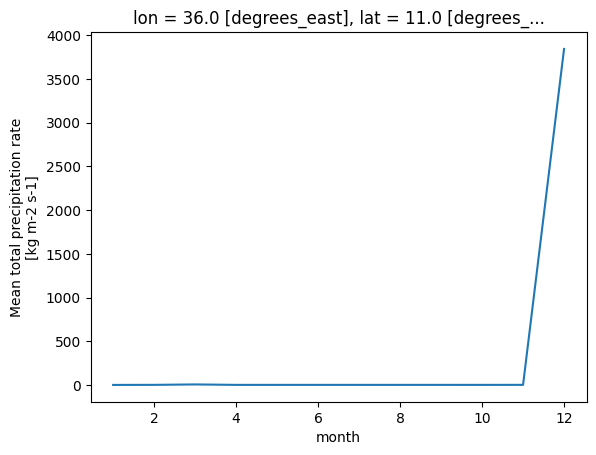

In [139]:
residuals_fine_1e6.sel(lat=11, lon=36).groupby('time.month').mean().plot()

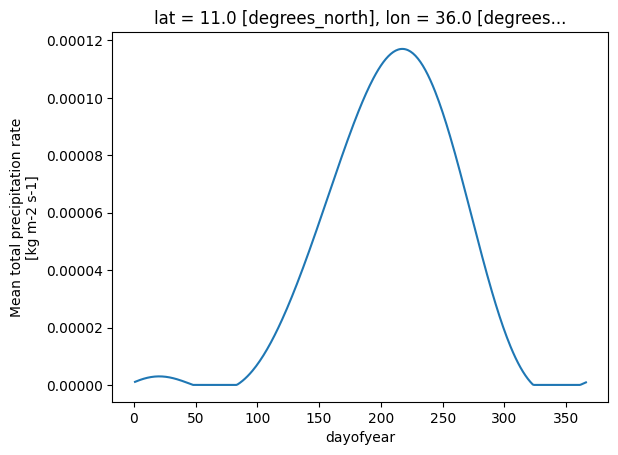

In [144]:
obs_fine_doy_means.sel(lat=11, lon=36).plot()